공공데이터포털에서 공휴일 데이터를 수집 중입니다...
요일 컬럼 패턴을 분석하여 정확한 날짜 시퀀스를 복원했습니다.
늑구 탈출 사건 운영 중단 기간(2026-04-08 ~ 2026-06-03) 데이터 57행을 제외했습니다.
정규화 적용된 피처: ['temperature', 'humidity', 'rain']
최종 전처리 파일 저장 완료: Oworld_final_processed.csv

[피처 간 상관관계 분석 결과]
              holiday   weekend       mon       tue       wed      thur  \
holiday      1.000000 -0.055628  0.065017  0.022429  0.012926 -0.008993   
weekend     -0.055628  1.000000 -0.259039 -0.259039 -0.257308 -0.258174   
mon          0.065017 -0.259039  1.000000 -0.167464 -0.166345 -0.166905   
tue          0.022429 -0.259039 -0.167464  1.000000 -0.166345 -0.166905   
wed          0.012926 -0.257308 -0.166345 -0.166345  1.000000 -0.165790   
thur        -0.008993 -0.258174 -0.166905 -0.166905 -0.165790  1.000000   
fri         -0.019666 -0.258174 -0.166905 -0.166905 -0.165790 -0.166348   
sat         -0.041011  0.644325 -0.166905 -0.166905 -0.165790 -0.166348   
sun         -0.030807  0.646483 -0.167464 -0.167464 -0.166345 -0.166905   
temperature -0

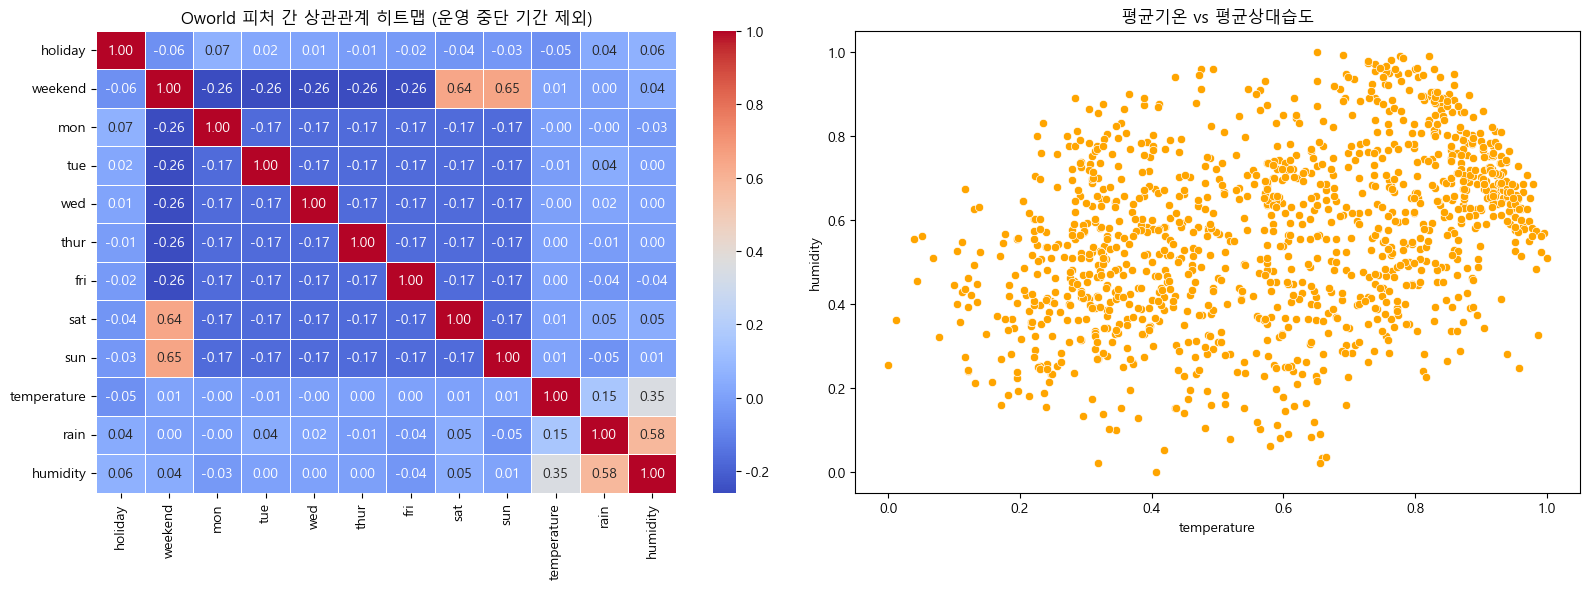

In [35]:
import os
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from dotenv import load_dotenv

# ==========================================
# 0. 환경 변수(.env) 로드 및 API 인증키 설정
# ==========================================
load_dotenv()
SERVICE_KEY = os.getenv("DATA_GO_KR_KEY")

if not SERVICE_KEY:
    raise ValueError(".env 파일에 'DATA_GO_KR_KEY' 인증키가 설정되어 있지 않습니다.")

# ==========================================
# 1. 2023년 1월 ~ 2026년 3월 공휴일 API 연동
# ==========================================
print("공공데이터포털에서 공휴일 데이터를 수집 중입니다...")
holiday_set = set()
url = "http://apis.data.go.kr/B090041/openapi/service/SpcdeInfoService/getRestDeInfo"

target_periods = []
for year in range(2023, 2027):
    for month in range(1, 13):
        if year == 2026 and month > 3:
            break
        target_periods.append((year, month))

for year, month in target_periods:
    params = {
        'serviceKey': SERVICE_KEY,
        'solYear': str(year),
        'solMonth': f"{month:02d}",
        'numOfRows': '100'
    }
    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            root = ET.fromstring(response.content)
            items = root.findall('.//item')
            for item in items:
                is_holiday = item.find('isHoliday')
                locdate = item.find('locdate')
                if is_holiday is not None and is_holiday.text == 'Y' and locdate is not None:
                    holiday_set.add(locdate.text)
    except Exception as e:
        print(f"경고: {year}년 {month}월 공휴일 데이터를 가져오는 중 오류 발생 - {e}")

# ==========================================
# 2. Oworld.csv 파일 로드 및 요일 컬럼 기반 날짜 복원
# ==========================================
if not os.path.exists('Oworld.csv'):
    raise FileNotFoundError("Oworld.csv 파일이 존재하지 않습니다.")

df = pd.read_csv('Oworld.csv', encoding='utf-8-sig')

# 요일 컬럼('mon', 'tue', 'wed', 'thur', 'fri', 'sat', 'sun')이 존재하므로 
# 이를 역산하여 각 행의 요일 번호(0:월 ~ 6:일)를 추출합니다.
day_cols = ['mon', 'tue', 'wed', 'thur', 'fri', 'sat', 'sun']
if all(col in df.columns for col in day_cols):
    # 각 행에서 값이 1인 요일의 인덱스(0~6)를 찾음
    day_matrix = df[day_cols].values
    weekday_indices = np.argmax(day_matrix, axis=1)
    
    # 데이터셋의 시작점(예: 2023년 1월 1일 일요일부터 시작하는 구조인지 확인)
    # 첫 행의 요일과 일치하는 2023년의 첫 날짜를 찾아 연속된 일자 배열을 생성합니다.
    base_dates = pd.date_range(start='2023-01-01', periods=len(df), freq='D')
    
    # 데이터의 요일 패턴과 일치하도록 첫 시작 요일을 보정
    first_row_weekday = weekday_indices[0]
    base_start_weekday = base_dates[0].weekday()
    offset = (first_row_weekday - base_start_weekday) % 7
    
    df['parsed_date'] = pd.date_range(start=pd.to_datetime('2023-01-01') + pd.Timedelta(days=int(offset)), 
                                      periods=len(df), freq='D')
    print("요일 컬럼 패턴을 분석하여 정확한 날짜 시퀀스를 복원했습니다.")
else:
    raise ValueError("필수 요일 컬럼(mon~sun)이 누락되어 있습니다.")

# API 공휴일 정보 반영
df['holiday'] = df['parsed_date'].dt.strftime('%Y%m%d').isin(holiday_set).astype(int)

# ==========================================
# 2-1. 늑구 탈출 사건 운영 중단 기간 (2026-04-08 ~ 2026-06-03) 제외
# ==========================================
start_suspend = pd.to_datetime('2026-04-08')
end_suspend = pd.to_datetime('2026-06-03')

initial_len = len(df)
df = df[~((df['parsed_date'] >= start_suspend) & (df['parsed_date'] <= end_suspend))]
excluded_count = initial_len - len(df)
print(f"늑구 탈출 사건 운영 중단 기간(2026-04-08 ~ 2026-06-03) 데이터 {excluded_count}행을 제외했습니다.")

# ==========================================
# 3. 데이터 전처리 및 정규화 (Normalization)
# ==========================================
numeric_features = ['temperature', 'humidity', 'rain']
valid_numeric_features = [col for col in numeric_features if col in df.columns and df[col].nunique() > 1]

if valid_numeric_features:
    scaler = MinMaxScaler()
    df[valid_numeric_features] = scaler.fit_transform(df[valid_numeric_features])
    print(f"정규화 적용된 피처: {valid_numeric_features}")

# 최종 전처리된 데이터셋 저장 (parsed_date 임시 컬럼 제외 저장 원할 경우 drop 가능)
output_filename = 'Oworld_final_processed.csv'
df.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"최종 전처리 파일 저장 완료: {output_filename}")


# ==========================================
# 4. 상관관계 분석 (Correlation Analysis)
# ==========================================
print("\n[피처 간 상관관계 분석 결과]")
target_col = next((col for col in ['target', '전체건수', '성인건수'] if col in df.columns), None)

corr_matrix = df.select_dtypes(include=[np.number]).corr()
if target_col:
    print(f"\n타겟 변수({target_col})와 다른 피처 간의 상관계수:")
    print(corr_matrix[target_col].sort_values(ascending=False))
else:
    print(corr_matrix)


# ==========================================
# 5. 그래프 시각화 (상관관계 히트맵 및 분포)
# ==========================================
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) 전체 수치형 피처 상관관계 히트맵
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0], linewidths=0.5)
axes[0].set_title('Oworld 피처 간 상관관계 히트맵 (운영 중단 기간 제외)')

# 2) 타겟 변수가 있는 경우 타겟과의 상관관계 바 플롯, 없으면 기온 vs 강수량 산점도
if target_col:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
    sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='crest')
    axes[1].set_title(f'타겟 변수({target_col})와의 상관계수 비교')
    axes[1].set_xlabel('상관계수')
    axes[1].set_ylabel('피처')
else:
    sns.scatterplot(x='temperature', y='humidity', data=df, ax=axes[1], color='orange')
    axes[1].set_title('평균기온 vs 평균상대습도')

plt.tight_layout()
plt.show()

결측치 제거 후 
- holiday와 weekend의 상관계수가 -0.0 -> API를 통해 실제 공휴일 날짜가 정확히 반영됨, 따라서 공휴일은 평일에도 고르게 분포되어 주말과의 상관관계가 줄어들었음. 

C:\Users\skdpa\AppData\Local\Temp\ipykernel_11160\2469282459.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['월', '화', '수', '목', '금', '토', '일'], y=day_means, ax=axes[0, 0], palette='Blues_d')
C:\Users\skdpa\AppData\Local\Temp\ipykernel_11160\2469282459.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['평일', '주말'], y=weekend_means.values, ax=axes[0, 1], palette=['lightcoral', 'lightgreen'])
C:\Users\skdpa\AppData\Local\Temp\ipykernel_11160\2469282459.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['일반일자', '휴일(공휴일)'], y=h

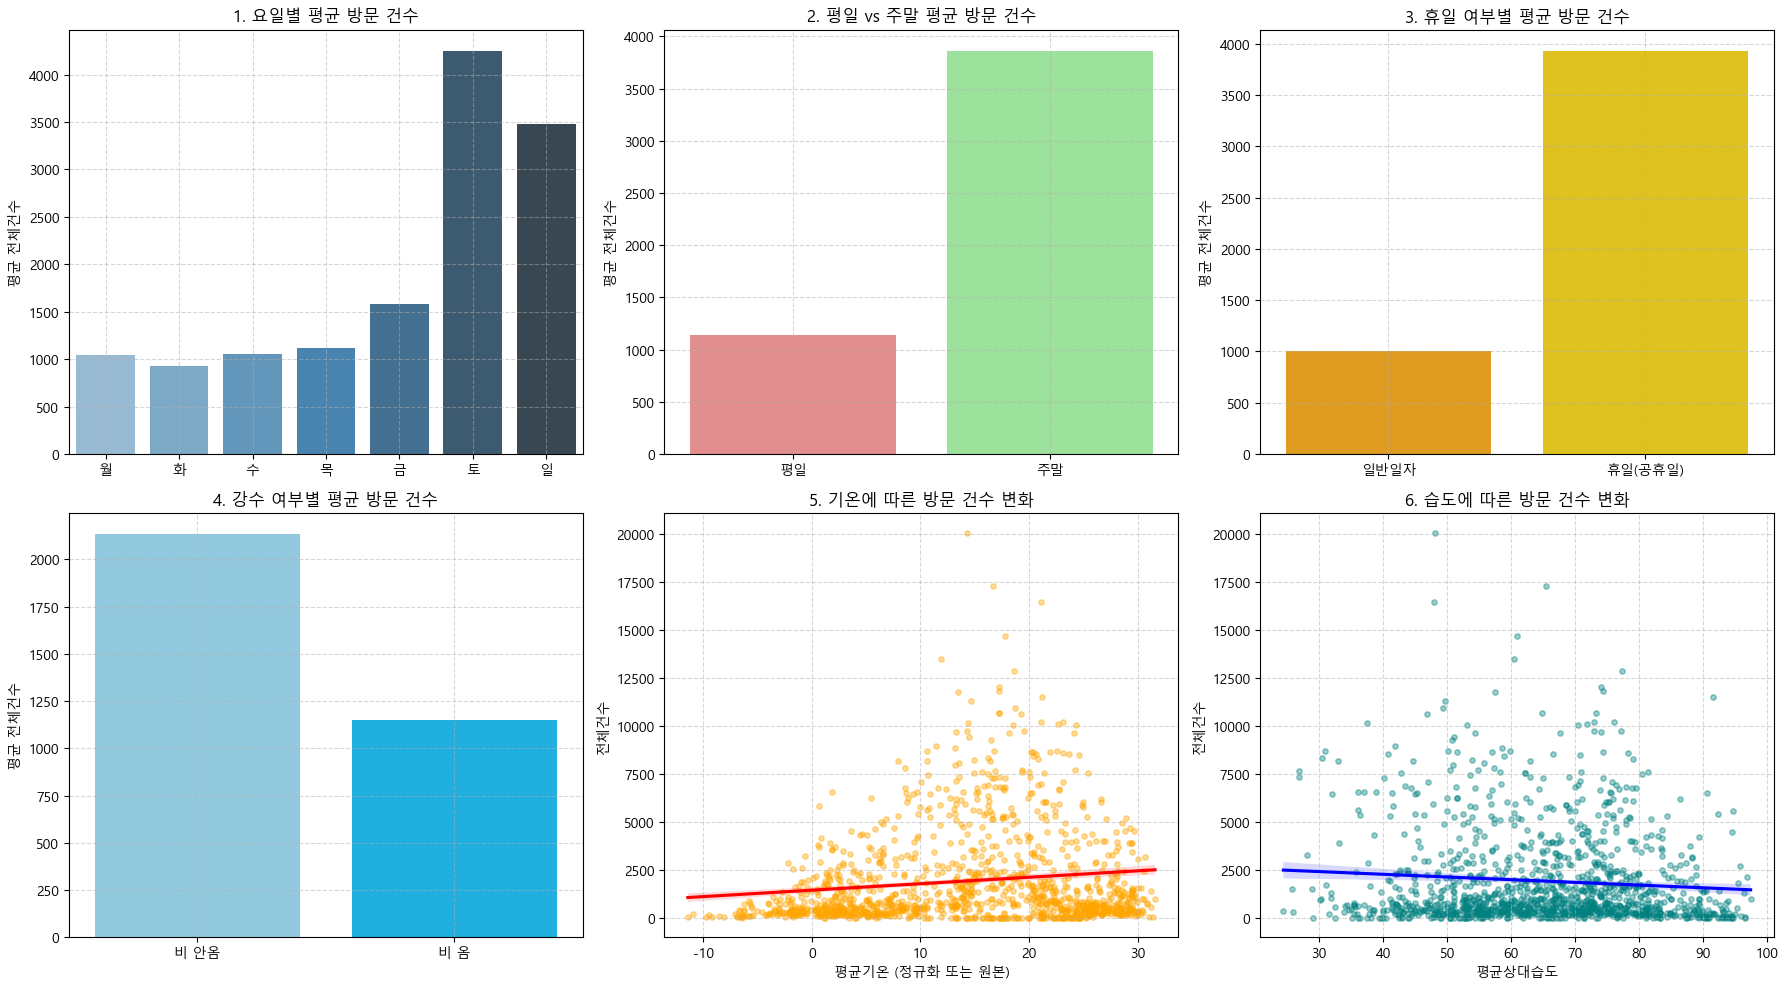

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기 및 타겟 컬럼 결합
df = pd.read_csv('Oworld.csv', encoding='utf-8-sig')

if os.path.exists('input.csv'):
    df_input = pd.read_csv('input.csv', encoding='utf-8-sig')
    # input.csv의 '전체건수'를 df에 'target' 컬럼으로 안전하게 결합
    if '전체건수' in df_input.columns:
        df['target'] = df_input['전체건수']
    else:
        df['target'] = df_input.iloc[:, 0]  # 첫 번째 컬럼을 타겟으로 지정
else:
    raise FileNotFoundError("input.csv 파일이 존재하지 않습니다.")

# 2행 3열의 서브플롯 캔버스 생성
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
target_col = 'target'

# 1. 첫 번째 그래프: 요일별 평균 전체건수 비교
days_cols = ['mon', 'tue', 'wed', 'thur', 'fri', 'sat', 'sun']
day_means = [df[df[d] == 1][target_col].mean() for d in days_cols]
sns.barplot(x=['월', '화', '수', '목', '금', '토', '일'], y=day_means, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('1. 요일별 평균 방문 건수')
axes[0, 0].set_ylabel('평균 전체건수')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. 두 번째 그래프: 주말(weekend) vs 평일 평균 건수 비교
weekend_means = df.groupby('weekend')[target_col].mean()
sns.barplot(x=['평일', '주말'], y=weekend_means.values, ax=axes[0, 1], palette=['lightcoral', 'lightgreen'])
axes[0, 1].set_title('2. 평일 vs 주말 평균 방문 건수')
axes[0, 1].set_ylabel('평균 전체건수')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3. 세 번째 그래프: 휴일(holiday) 여부별 평균 건수 비교
holiday_means = df.groupby('holiday')[target_col].mean()
sns.barplot(x=['일반일자', '휴일(공휴일)'], y=holiday_means.values, ax=axes[0, 2], palette=['orange', 'gold'])
axes[0, 2].set_title('3. 휴일 여부별 평균 방문 건수')
axes[0, 2].set_ylabel('평균 전체건수')
axes[0, 2].grid(True, linestyle='--', alpha=0.5)

# 4. 네 번째 그래프: 강수 여부별 평균 건수 비교
df['has_rain'] = (df['rain'] > 0)
rain_means = df.groupby('has_rain')[target_col].mean()
sns.barplot(x=['비 안옴', '비 옴'], y=rain_means.values, ax=axes[1, 0], palette=['skyblue', 'deepskyblue'])
axes[1, 0].set_title('4. 강수 여부별 평균 방문 건수')
axes[1, 0].set_ylabel('평균 전체건수')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 5. 다섯 번째 그래프: 기온에 따른 타겟 건수 변화 (산점도 + 회귀선)
sns.regplot(x='temperature', y=target_col, data=df, ax=axes[1, 1], color='orange', 
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'red'})
axes[1, 1].set_title('5. 기온에 따른 방문 건수 변화')
axes[1, 1].set_xlabel('평균기온 (정규화 또는 원본)')
axes[1, 1].set_ylabel('전체건수')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# 6. 여섯 번째 그래프: 습도에 따른 타겟 건수 변화 (산점도 + 회귀선)
sns.regplot(x='humidity', y=target_col, data=df, ax=axes[1, 2], color='teal', 
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'blue'})
axes[1, 2].set_title('6. 습도에 따른 방문 건수 변화')
axes[1, 2].set_xlabel('평균상대습도')
axes[1, 2].set_ylabel('전체건수')
axes[1, 2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()